**DBSCAN algorithm implementation in python**

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [2]:
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.50, random_state=0)

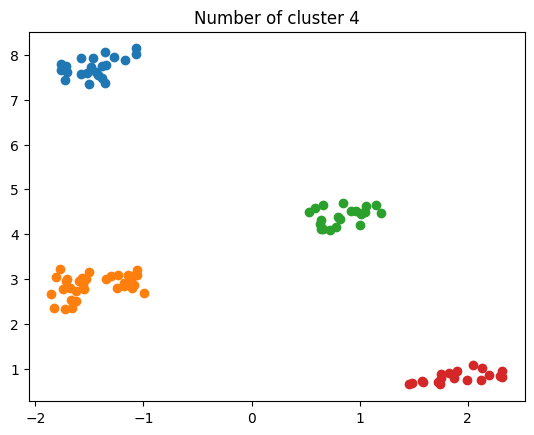

In [6]:
db = DBSCAN(eps=0.3, min_samples=10).fit(X)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

labels = db.labels_

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

unique_labels = set(labels)
colors = ['y', 'g', 'b', 'r']
for K, col in zip(unique_labels, colors):
  if K == -1:
    col = 'k'
  
  class_member_mask = (labels == K)
  xy = X[class_member_mask & core_samples_mask]
  plt.plot(xy[:,0], xy[:,1], 'o', markersize=6)

plt.title(f'Number of cluster {n_clusters}')
plt.show()

In [7]:
from sklearn import metrics

sc = metrics.silhouette_score(X, labels)
print("Silhouette Coefficient:%0.2f" % sc)
ari = metrics.adjusted_rand_score(y_true, labels)
print("Adjusted Rand Index: %0.2f" % ari)

Silhouette Coefficient:0.13
Adjusted Rand Index: 0.31
